<a href="https://colab.research.google.com/github/guilhermelaviola/DataScienceApplicationsInComputerVision/blob/main/Class11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **R Applications in Computer Vision**
The R language has established itself as a versatile tool for computer vision, especially through the EBImage package, which allows for everything from basic processing to advanced techniques such as Gaussian filtering, edge detection, and Fourier transform. R's major advantage lies in its ability to integrate with Python via packages like reticulate and rpy2, allowing developers to combine R's statistical and visualization excellence with the power of machine learning libraries (OpenCV, TensorFlow, and PyTorch). This synergy, applicable in sectors such as medicine and security, creates a robust workflow that efficiently and flexibly transforms visual data into valuable statistical insights.

In [1]:
# Importing all the necessary libraries and resources:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import numpy as np

In [2]:
# Function to upload an image:
uploaded = files.upload()

# Loading the image:
image_path = next(iter(uploaded))
img = Image.open(image_path)
img = np.array(img)

# Converting to RGB if necessary (if the image has transparency):
if img.shape[-1] == 4:
  img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)

Saving basquiat-02.webp to basquiat-02.webp


Text(0.5, 1.0, 'Original image')

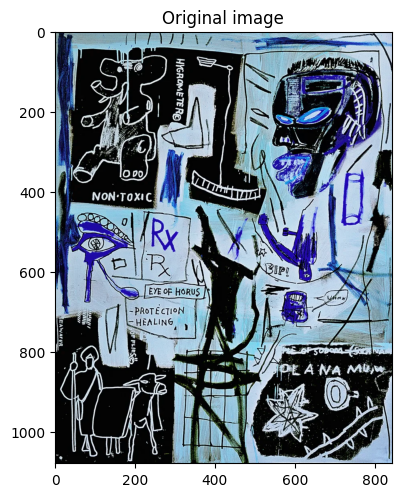

In [3]:
# Displaying the original image:
plt.figure(figsize=(20,10))
plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original image')

Text(0.5, 1.0, 'Image in grayscale')

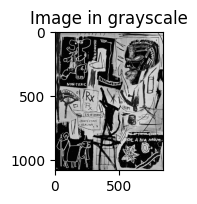

In [4]:
# Converting to grayscale:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Displaying the image in grayscale:
plt.subplot(1, 4, 2)
plt.imshow(img_gray, cmap='gray')
plt.title('Image in grayscale')

## **Example: Gaussian Filter**
A Gaussian filter is a linear, smoothing operator used in image and signal processing to reduce noise and detail by blurring, based on the bell-shaped Gaussian distribution. It works by calculating a weighted average of surrounding pixels, with more weight given to the central pixel, making it superior to box filters for preserving some edge information while removing noise.

Text(0.5, 1.0, 'Smoothed image (Gaussian filter)')

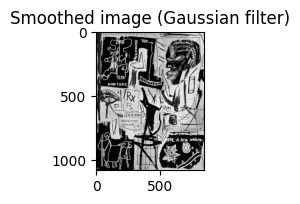

In [5]:
# Applying Gaussian filter for smoothing the image:
img_blur= cv2.GaussianBlur(img_gray, (5, 5), 0)

# Displaying the smoothed image:
plt.subplot(1, 4, 3)
plt.imshow(img_blur, cmap='gray')
plt.title('Smoothed image (Gaussian filter)')

## **Example: Sobel Filter**
The Sobel filter is a popular image processing operator used for edge detection by calculating an approximation of the image gradient. It highlights regions of high spatial frequency (edges) by computing the horizontal and vertical intensity changes, usually via two 3x3 convolution kernels.

Text(0.5, 1.0, 'Edge detection (Sobel filter)')

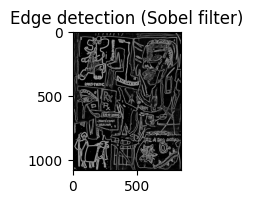

In [6]:
# Applying Sobel filter for edge detection:
sobel_x = cv2.Sobel(img_blur, cv2.CV_64F, 1, 0, ksize=3) # Horizontal
sobel_y= cv2.Sobel(img_blur, cv2.CV_64F, 0, 1, ksize=3) # Vertical
img_edges = cv2.magnitude(sobel_x, sobel_y)

# Displaying the image with detected edges:
plt.subplot(1, 4, 4)
plt.imshow(img_edges, cmap='gray')
plt.title('Edge detection (Sobel filter)')

In [7]:
# Showing all images for comparison:
plt.show()